Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
              ID M/F Hand  Age  Educ  SES  MMSE  CDR  eTIV   nWBV    ASF  \
0  OAS1_0001_MR1   F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306   
1  OAS1_0002_MR1   F    R   55   4.0  1.0  29.0  0.0  1147  0.810  1.531   
2  OAS1_0003_MR1   F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207   
3  OAS1_0004_MR1   M    R   28   NaN  NaN   NaN  0.0  1588  0.803  1.105   
4  OAS1_0005_MR1   M    R   18   NaN  NaN   NaN  0.0  1737  0.848  1.010   

   Delay  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

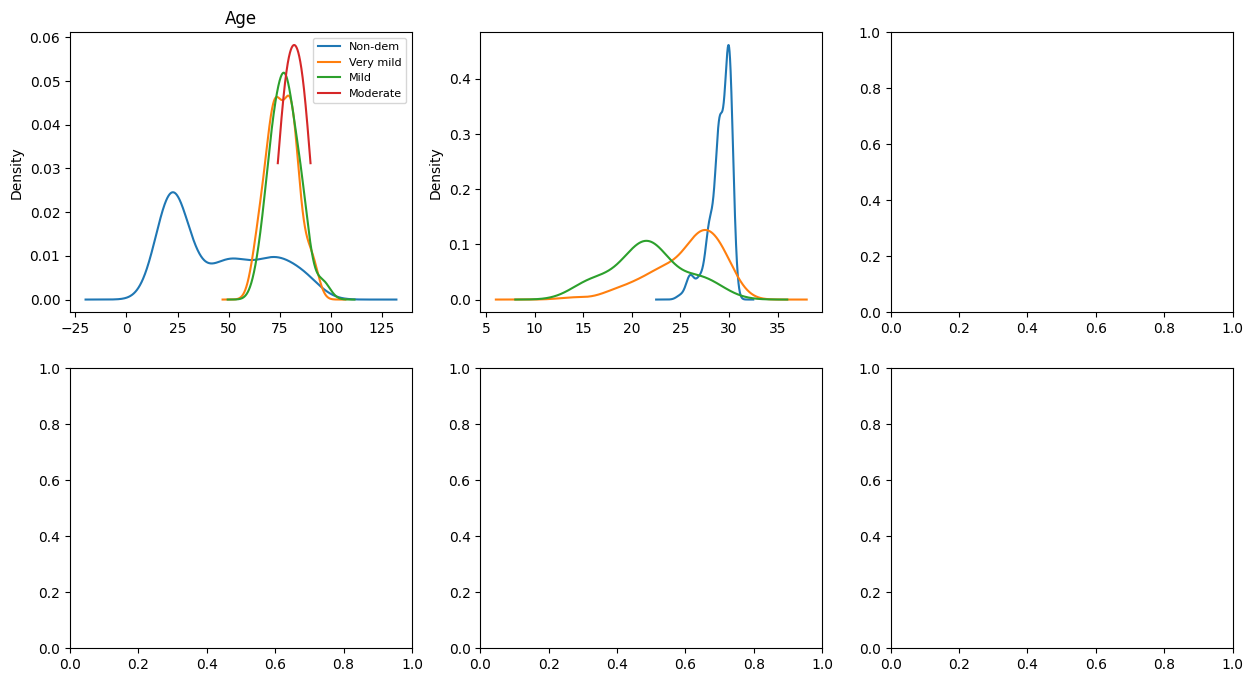

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')
BASE_PATH = "/content/drive/MyDrive/dataset/data"
csv_path = f"{BASE_PATH}/oasis_cross-sectional.csv"
df = pd.read_csv(csv_path)

print(df.head())
cdr_labels = {0.0: 'Non-dem', 0.5: 'Very mild', 1.0: 'Mild', 2.0: 'Moderate'}
df['CDR_label'] = df['CDR'].map(cdr_labels)

FEATURES = ['Age', 'MMSE', 'nWBV', 'eTIV', 'Educ', 'SES']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), FEATURES):
    for cdr_val, label in cdr_labels.items():
        subset = df[df['CDR'] == cdr_val][feat].dropna()
        subset.plot.kde(ax=ax, label=label)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.suptitle('Feature distributions per CDR class', fontsize=14)
plt.tight_layout()
plt.show()
# This plot alone is a thesis figure — it shows which features
# separate the classes and which overlap